# Engineering Acoustics

## Exercise 1

Engineers must understand the physical size of the waves they are trying to manipulate, especially when designing acoustic panels.

---
Task:
* Calculate the wavelength $\lambda$ for a "Bass" note (60 Hz) and a "Treble" note (10,000 Hz) using a constant speed of sound $c = 343 \text{ m/s}$ at $20^\circ\text{C}$.
* Discussion: Why is it harder to absorb low frequencies using thin foam panels based on their physical wavelength?

In [1]:
import numpy as np

# Constants
## your code for c, f_bass, f_treble 


# Wavelength calculation: lambda = c / f
## your code for lambda_bass, lambda_treble


print(f"Bass Wavelength (60 Hz): {lambda_bass:.2f} meters")
print(f"Treble Wavelength (10 kHz): {lambda_treble:.2f} meters")

Bass Wavelength (60 Hz): 5.72 meters
Treble Wavelength (10 kHz): 0.03 meters


## Exercise 2

Sound speed is not constant; it fluctuates with temperature, affecting everything from sonar accuracy to outdoor concert synchronisation.

---
Task:
* Define a temperature range from $-20^\circ\text{C}$ to $40^\circ\text{C}$.
* Calculate the speed of sound $c$ using the thermodynamic formula: $c = 331.3 \sqrt{1 + \frac{T}{273.15}}$.
* Plot the relationship.
* Define new temperature range from $-270^\circ\text{C}$ to $400^\circ\text{C}$ and repeat all steps.

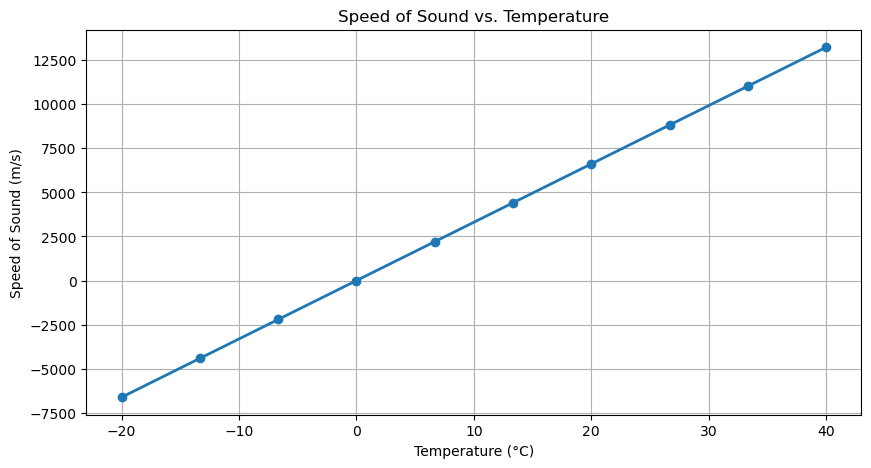

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Temperature range from -20 to 40 degrees Celsius
## your code for T

# Speed of sound formula
## your code for c


# Plotting
plt.figure(figsize=(10, 5))
plt.plot(T, c, linewidth=2, marker='o')
plt.title('Speed of Sound vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Speed of Sound (m/s)')
plt.grid(True)
plt.show()

## Exercise 3

The human ear perceives sound logarithmically, moving from a tiny "threshold of hearing" to a "pain threshold".

---
Task:
* Convert RMS pressure ($p_{rms}$) in Pascals to Decibels (dB) using the formula: $L_p = 20 \log_{10}(\frac{p_{rms}}{p_{ref}})$.
* Test the code with: 0.02 Pa (Office), 2.0 Pa (Loud Factory), and 20.0 Pa (Threshold of Pain).

In [3]:
# Constants
p_rms = np.array([0.02, 2.0, 20.0])
labels = ['Office', 'Loud Factory', 'Pain Threshold'] 

# SPL formula calculation
## your code for p_ref and Lp


for label, db in zip(labels, Lp):
    print(f"{label}: {db:.1f} dB") 

Office: 60.0 dB
Loud Factory: 100.0 dB
Pain Threshold: 120.0 dB


## Exercise 4

When designing a room, total energy is the sum of reflected, absorbed, and transmitted energy. For simplicity can use: 

$E_{incident} = E_{refl} + E_{abs}$.

---
Task:
* Calculate reflected energy for Concrete ($\alpha=0.02$), Wood ($\alpha=0.10$), and Acoustic Foam ($\alpha=0.85$).
* Visualize the results in a stacked bar chart, decribing the physical phenomenon you observed.

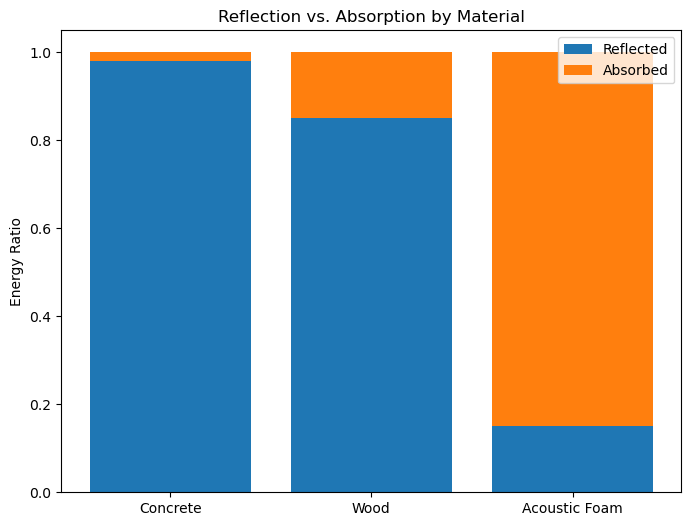

In [4]:
E_incident = 1.0 
materials = ['Concrete', 'Wood', 'Acoustic Foam']
alpha = np.array([0.02, 0.15, 0.85]) # Absorption coefficients

# Energy calculations 
## your code for E_abs and E_refl


plt.figure(figsize=(8, 6))
plt.bar(materials, E_refl, label='Reflected')
plt.bar(materials, E_abs, bottom=E_refl, label='Absorbed')
plt.ylabel('Energy Ratio')
plt.title('Reflection vs. Absorption by Material')
plt.legend()
plt.show()

## Exercise 5

In architectural acoustics, "specular reflection" ($\theta_i = \theta_r$) is used to map how sound travels in concert halls.

---
Task:
* Simulate a sound source at (0, 0) and a wall at $x = 10$.
* Calculate the trajectory of a ray hitting the wall at an incident angle of $30^\circ$ relative to the normal.

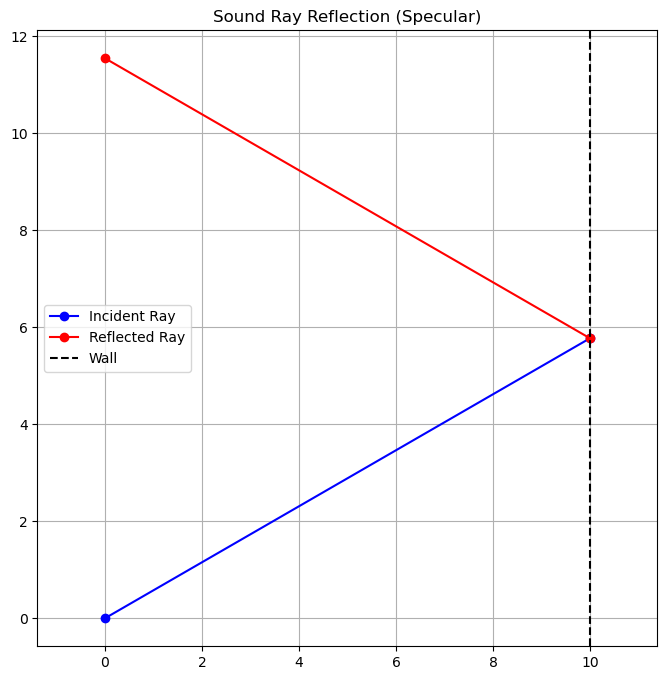

In [5]:
theta_i = np.radians(30)
source = np.array([0, 0])

# Calculate Hit Point 
## your code for wall_x, dx, dy



hit_point = np.array([wall_x, dy])

# Reflected Point (Law of Reflection: theta_r = theta_i) 
end_point = np.array([source[0], 2 * dy])

plt.figure(figsize=(8, 8))
plt.plot([source[0], hit_point[0]], [source[1], hit_point[1]], 'b-o', label='Incident Ray')
plt.plot([hit_point[0], end_point[0]], [hit_point[1], end_point[1]], 'r-o', label='Reflected Ray')
plt.axvline(x=wall_x, color='k', linestyle='--', label='Wall')
plt.title('Sound Ray Reflection (Specular)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## Independent Work

### Environmental Impact on Tuning

In outdoor concerts, temperature gradients can shift the perceived pitch of instruments because the wavelength of a constant frequency changes with the speed of sound.

**Task**:
* Suppose an orchestra tunes their instruments to $A4 = 440\text{ Hz}$ at a rehearsal temperature of $20^{\circ}\text{C}$.
* Write a script to calculate how much the wavelength $\lambda$ of that $440\text{ Hz}$ note changes if the performance takes place at $5^{\circ}\text{C}$.
* Calculate the "new" frequency a listener would hear if the instrument's physical length (which dictates wavelength) remained constant, but the air temperature dropped to $5^{\circ}\text{C}$.

### Cumulative Sound Exposure

In industrial environments, engineers must calculate the total Sound Pressure Level (SPL) when multiple machines are running simultaneously. Decibels cannot be added linearly; you must sum the underlying pressures or intensities.

**Task**:
* A factory has three machines producing $85\text{ dB}$, $92\text{ dB}$, and $88\text{ dB}$ respectively.
* Write a function that:Converts these $L_p$ values back to RMS pressure ($p_{rms}$) using $p_{ref} = 20\mu\text{Pa}$.
* Calculates the total $p_{rms}$ using the root-sum-square method: $p_{total} = \sqrt{p_1^2 + p_2^2 + p_3^2}$.
* Converts the total pressure back into a final $L_p$ (dB) value.
* Determine if the combined noise exceeds the "Pain Threshold" mentioned in the lecture.